In [1]:
# DAY 5: DATA VISUALIZATION & INSIGHTS
# FreshBite Bakery - Inventory Waste Analysis


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set visual style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("="*60)
print("DATA VISUALIZATION & BUSINESS INSIGHTS")
print("="*60)

DATA VISUALIZATION & BUSINESS INSIGHTS


In [2]:
# SECTION 1: LOAD QUERY RESULTS

print("\n[SECTION 1] Loading Query Results...")

q1 = pd.read_csv('query1_top_spoilage_products.csv')
q2 = pd.read_csv('query2_top_waste_cost.csv')
q3 = pd.read_csv('query3_spoilage_by_store.csv')
q4 = pd.read_csv('query4_spoilage_by_category.csv')
q5 = pd.read_csv('query5_monthly_trend.csv')
q6 = pd.read_csv('query6_weekend_weekday.csv')
q7 = pd.read_csv('query7_high_waste_low_sales.csv')
q8 = pd.read_csv('query8_store_comparison.csv')

print("✓ All query results loaded")


[SECTION 1] Loading Query Results...
✓ All query results loaded



[VIZ 1] Top 10 Products by Spoilage Volume


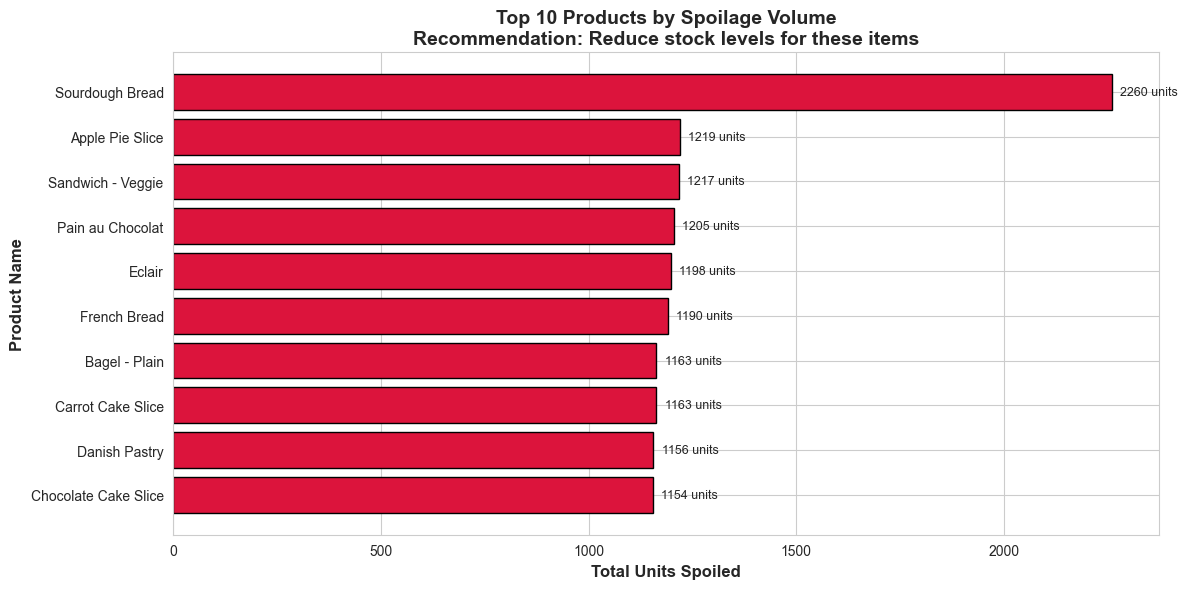

💡 INSIGHT: Top product 'Sourdough Bread' wasted 2260 units
   ACTION: Reduce daily stock by 30% for top 3 products


In [4]:
# VISUALIZATION 1: Top 10 Products by Spoilage
# ============================================
print("\n" + "="*60)
print("[VIZ 1] Top 10 Products by Spoilage Volume")
print("="*60)

plt.figure(figsize=(12, 6))
bars = plt.barh(q1['product_name'], q1['total_spoiled'], color='crimson', edgecolor='black')
plt.xlabel('Total Units Spoiled', fontsize=12, fontweight='bold')
plt.ylabel('Product Name', fontsize=12, fontweight='bold')
plt.title('Top 10 Products by Spoilage Volume\nRecommendation: Reduce stock levels for these items', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 20, bar.get_y() + bar.get_height()/2, 
             f'{int(width)} units', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('viz1_top_spoilage_products.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"💡 INSIGHT: Top product '{q1.iloc[0]['product_name']}' wasted {int(q1.iloc[0]['total_spoiled'])} units")
print("   ACTION: Reduce daily stock by 30% for top 3 products")


[VIZ 2] Top 10 Products by Waste Cost


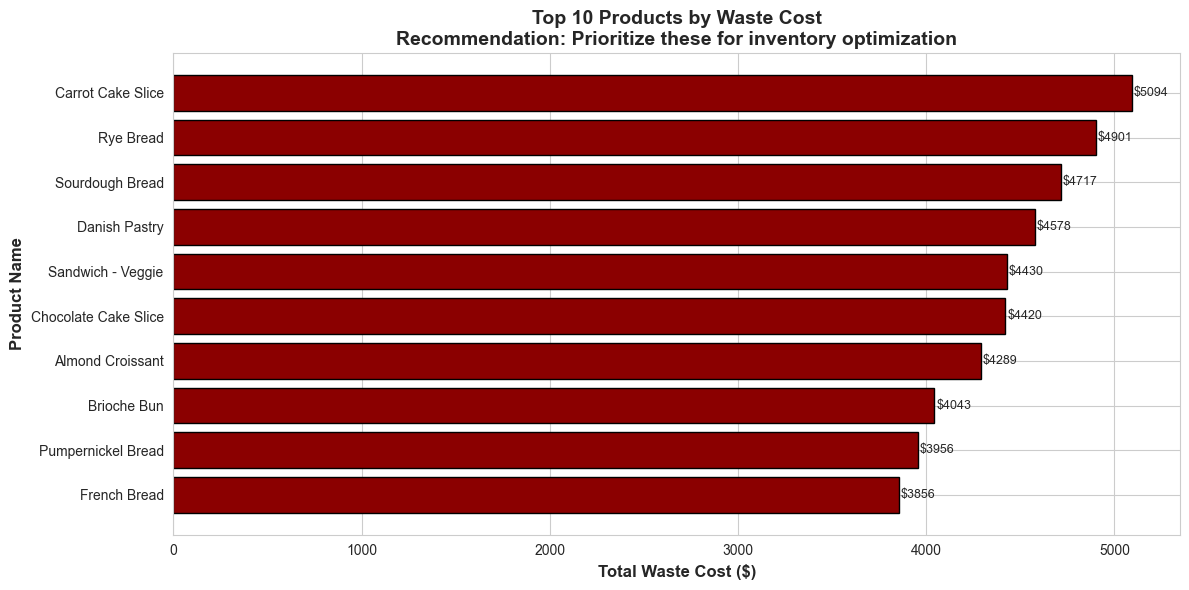

💡 INSIGHT: Top 10 products cost $44283.10 in waste
   ACTION: Focus on high-cost items first for maximum savings


In [5]:
# VISUALIZATION 2: Top 10 Products by Waste Cost
# ============================================
print("\n" + "="*60)
print("[VIZ 2] Top 10 Products by Waste Cost")
print("="*60)

plt.figure(figsize=(12, 6))
bars = plt.barh(q2['product_name'], q2['total_waste_cost'], color='darkred', edgecolor='black')
plt.xlabel('Total Waste Cost ($)', fontsize=12, fontweight='bold')
plt.ylabel('Product Name', fontsize=12, fontweight='bold')
plt.title('Top 10 Products by Waste Cost\nRecommendation: Prioritize these for inventory optimization', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    plt.text(width + 10, bar.get_y() + bar.get_height()/2, 
             f'${width:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('viz2_top_waste_cost.png', dpi=300, bbox_inches='tight')
plt.show()

total_waste = q2['total_waste_cost'].sum()
print(f"💡 INSIGHT: Top 10 products cost ${total_waste:.2f} in waste")
print("   ACTION: Focus on high-cost items first for maximum savings")


[VIZ 3] Spoilage by Store Location


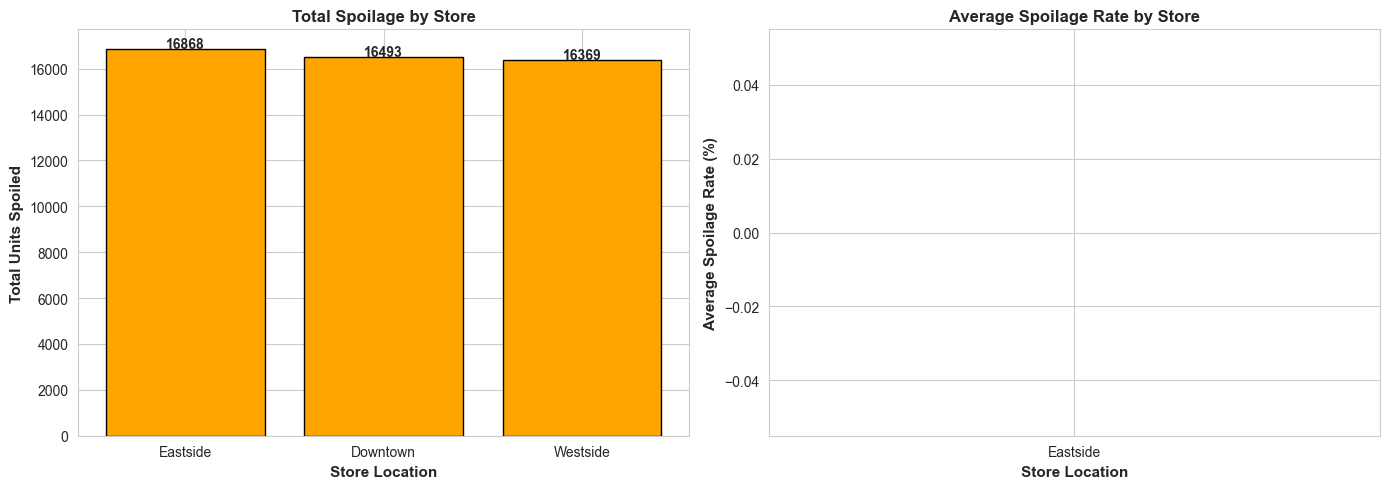

💡 INSIGHT: Eastside has highest spoilage
   ACTION: Investigate Eastside operations - training needed?


In [6]:
# VISUALIZATION 3: Spoilage by Store
# ============================================
print("\n" + "="*60)
print("[VIZ 3] Spoilage by Store Location")
print("="*60)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Total spoilage
ax1.bar(q3['store_location'], q3['total_spoiled'], color='orange', edgecolor='black')
ax1.set_xlabel('Store Location', fontsize=11, fontweight='bold')
ax1.set_ylabel('Total Units Spoiled', fontsize=11, fontweight='bold')
ax1.set_title('Total Spoilage by Store', fontsize=12, fontweight='bold')
for i, v in enumerate(q3['total_spoiled']):
    ax1.text(i, v + 50, str(int(v)), ha='center', fontweight='bold')

# Spoilage rate
ax2.bar(q3['store_location'], q3['avg_spoilage_rate_pct'], color='coral', edgecolor='black')
ax2.set_xlabel('Store Location', fontsize=11, fontweight='bold')
ax2.set_ylabel('Average Spoilage Rate (%)', fontsize=11, fontweight='bold')
ax2.set_title('Average Spoilage Rate by Store', fontsize=12, fontweight='bold')
for i, v in enumerate(q3['avg_spoilage_rate_pct']):
    ax2.text(i, v + 0.1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('viz3_spoilage_by_store.png', dpi=300, bbox_inches='tight')
plt.show()

worst_store = q3.iloc[0]['store_location']
print(f"💡 INSIGHT: {worst_store} has highest spoilage")
print(f"   ACTION: Investigate {worst_store} operations - training needed?")


[VIZ 4] Spoilage by Category


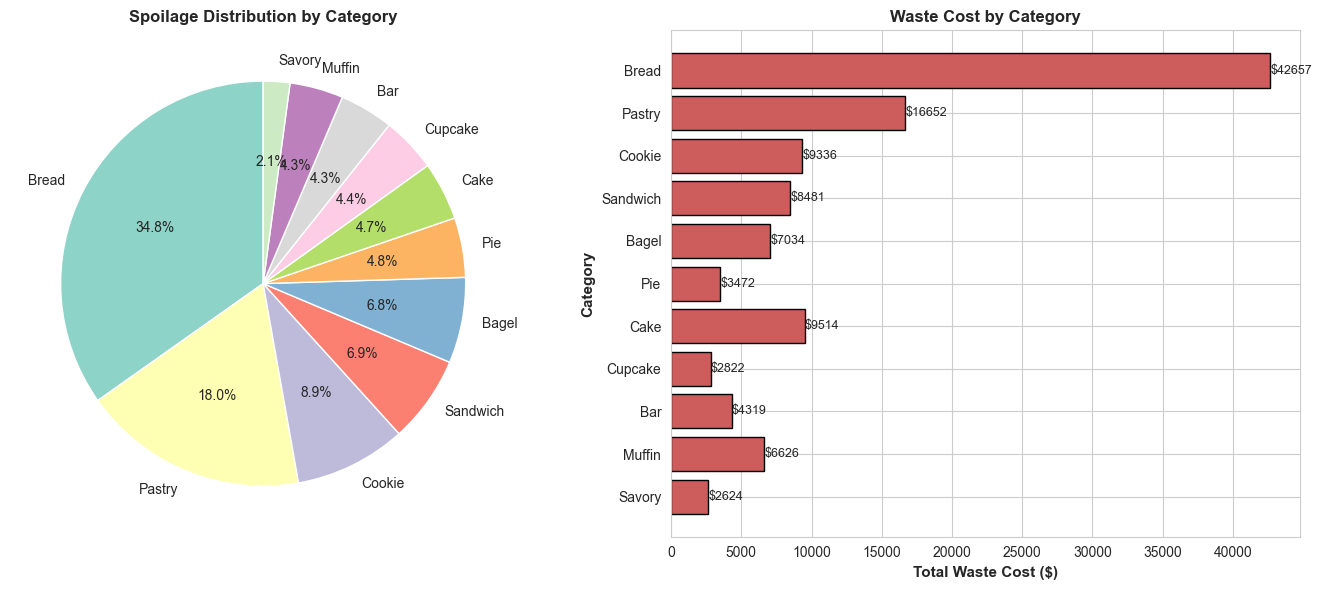

💡 INSIGHT: Bread category has highest waste
   ACTION: Review Bread shelf life and reorder quantities


In [8]:
# VISUALIZATION 4: Spoilage by Category
# ============================================
print("\n" + "="*60)
print("[VIZ 4] Spoilage by Category")
print("="*60)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Pie chart - total spoilage
colors = plt.cm.Set3(range(len(q4)))
ax1.pie(q4['total_spoiled'], labels=q4['category'], autopct='%1.1f%%', 
        startangle=90, colors=colors, textprops={'fontsize': 10})
ax1.set_title('Spoilage Distribution by Category', fontsize=12, fontweight='bold')

# Bar chart - waste cost
bars = ax2.barh(q4['category'], q4['total_waste_cost'], color='indianred', edgecolor='black')
ax2.set_xlabel('Total Waste Cost ($)', fontsize=11, fontweight='bold')
ax2.set_ylabel('Category', fontsize=11, fontweight='bold')
ax2.set_title('Waste Cost by Category', fontsize=12, fontweight='bold')
ax2.invert_yaxis()
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax2.text(width + 20, bar.get_y() + bar.get_height()/2, 
             f'${width:.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('viz4_spoilage_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

top_category = q4.iloc[0]['category']
print(f"💡 INSIGHT: {top_category} category has highest waste")
print(f"   ACTION: Review {top_category} shelf life and reorder quantities")


[VIZ 5] Monthly Spoilage Trend


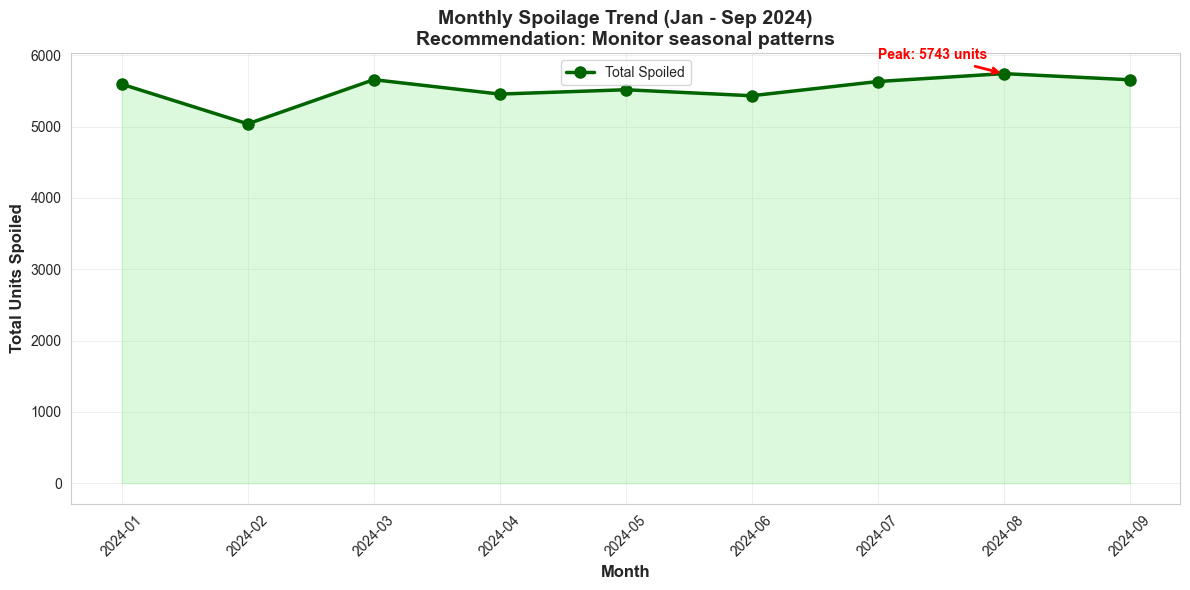

💡 INSIGHT: Peak spoilage in 2024-08
   ACTION: Adjust inventory forecast for seasonal demand


In [9]:
# VISUALIZATION 5: Monthly Spoilage Trend
# ============================================
print("\n" + "="*60)
print("[VIZ 5] Monthly Spoilage Trend")
print("="*60)

plt.figure(figsize=(12, 6))
plt.plot(q5['month'], q5['total_spoiled'], marker='o', linewidth=2.5, 
         color='darkgreen', markersize=8, label='Total Spoiled')
plt.fill_between(range(len(q5)), q5['total_spoiled'], alpha=0.3, color='lightgreen')
plt.xlabel('Month', fontsize=12, fontweight='bold')
plt.ylabel('Total Units Spoiled', fontsize=12, fontweight='bold')
plt.title('Monthly Spoilage Trend (Jan - Sep 2024)\nRecommendation: Monitor seasonal patterns', 
          fontsize=14, fontweight='bold')
plt.xticks(range(len(q5)), q5['month'], rotation=45)
plt.grid(alpha=0.3)
plt.legend()

# Add trend annotation
max_month = q5.loc[q5['total_spoiled'].idxmax(), 'month']
max_value = q5['total_spoiled'].max()
plt.annotate(f'Peak: {int(max_value)} units', 
             xy=(q5['total_spoiled'].idxmax(), max_value),
             xytext=(q5['total_spoiled'].idxmax()-1, max_value+200),
             arrowprops=dict(arrowstyle='->', color='red', lw=2),
             fontsize=10, fontweight='bold', color='red')

plt.tight_layout()
plt.savefig('viz5_monthly_trend.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"💡 INSIGHT: Peak spoilage in {max_month}")
print("   ACTION: Adjust inventory forecast for seasonal demand")


[VIZ 6] Weekend vs Weekday Spoilage


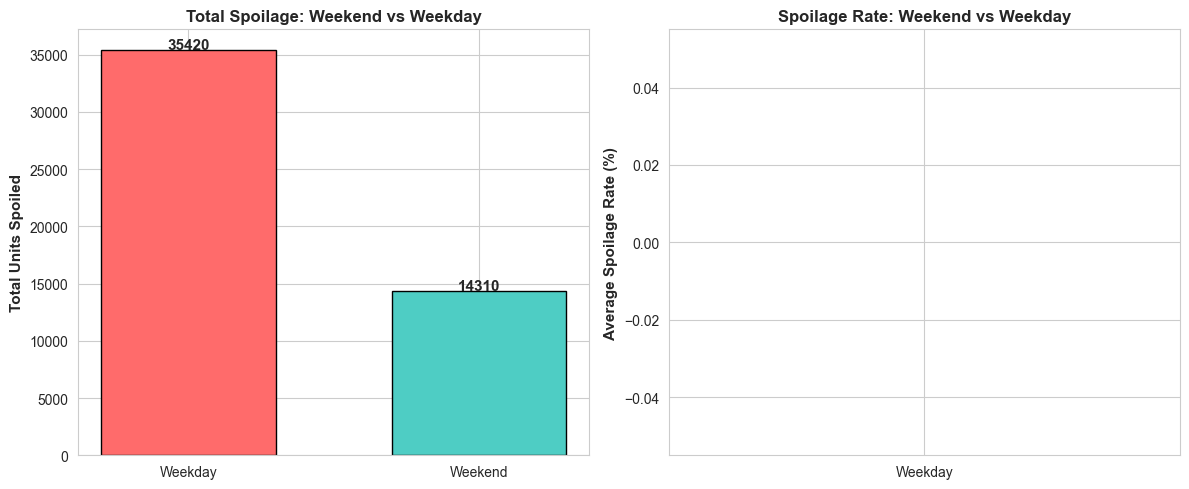

💡 INSIGHT: Weekday has higher spoilage
   ACTION: Adjust weekend vs weekday stock levels accordingly


In [10]:
# VISUALIZATION 6: Weekend vs Weekday
# ============================================
print("\n" + "="*60)
print("[VIZ 6] Weekend vs Weekday Spoilage")
print("="*60)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Total spoilage
colors_day = ['#FF6B6B', '#4ECDC4']
ax1.bar(q6['day_type'], q6['total_spoiled'], color=colors_day, edgecolor='black', width=0.6)
ax1.set_ylabel('Total Units Spoiled', fontsize=11, fontweight='bold')
ax1.set_title('Total Spoilage: Weekend vs Weekday', fontsize=12, fontweight='bold')
for i, v in enumerate(q6['total_spoiled']):
    ax1.text(i, v + 100, str(int(v)), ha='center', fontweight='bold', fontsize=11)

# Spoilage rate
ax2.bar(q6['day_type'], q6['avg_spoilage_rate_pct'], color=colors_day, edgecolor='black', width=0.6)
ax2.set_ylabel('Average Spoilage Rate (%)', fontsize=11, fontweight='bold')
ax2.set_title('Spoilage Rate: Weekend vs Weekday', fontsize=12, fontweight='bold')
for i, v in enumerate(q6['avg_spoilage_rate_pct']):
    ax2.text(i, v + 0.05, f'{v:.2f}%', ha='center', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('viz6_weekend_weekday.png', dpi=300, bbox_inches='tight')
plt.show()

if q6.iloc[0]['day_type'] == 'Weekend':
    higher_day = 'Weekend'
else:
    higher_day = 'Weekday'
print(f"💡 INSIGHT: {higher_day} has higher spoilage")
print("   ACTION: Adjust weekend vs weekday stock levels accordingly")


[VIZ 7] High Waste + Low Sales Products


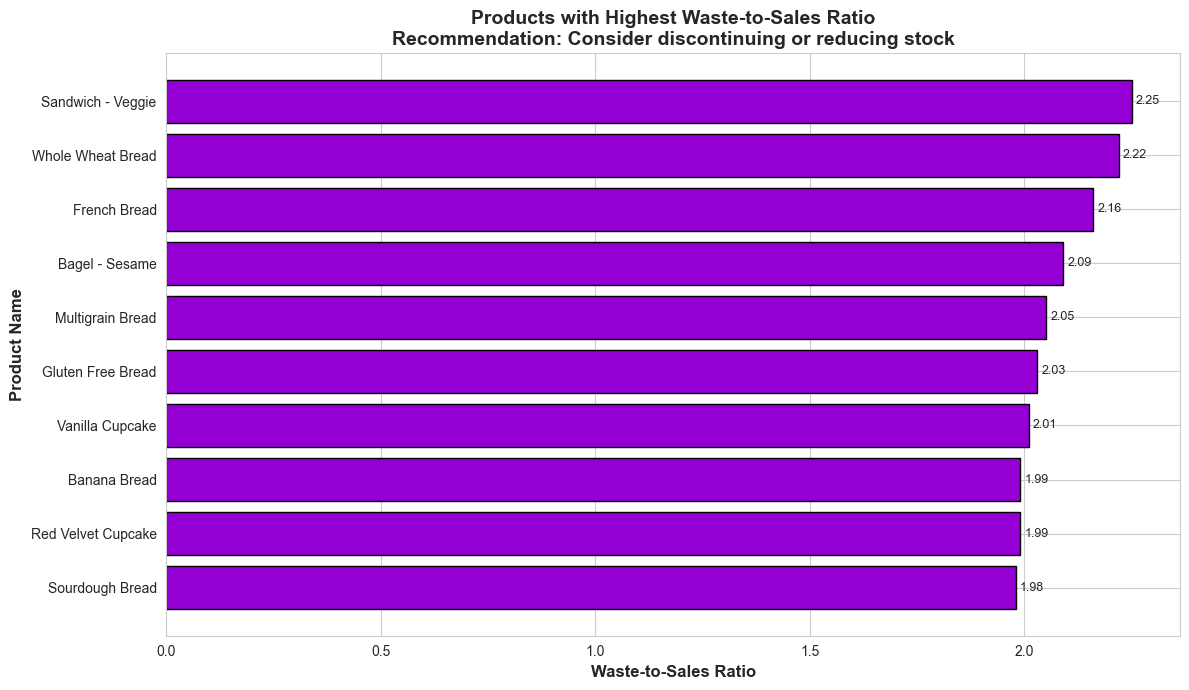

💡 INSIGHT: 15 products have high waste relative to sales
   ACTION: Discontinue top 3 low-performing products or switch to made-to-order


In [12]:
# VISUALIZATION 7: High Waste Low Sales Products
# ============================================
print("\n" + "="*60)
print("[VIZ 7] High Waste + Low Sales Products")
print("="*60)

# Take top 10 for visualization
q7_top10 = q7.head(10)

plt.figure(figsize=(12, 7))
bars = plt.barh(q7_top10['product_name'], q7_top10['waste_to_sales_ratio'], 
                color='darkviolet', edgecolor='black')
plt.xlabel('Waste-to-Sales Ratio', fontsize=12, fontweight='bold')
plt.ylabel('Product Name', fontsize=12, fontweight='bold')
plt.title('Products with Highest Waste-to-Sales Ratio\nRecommendation: Consider discontinuing or reducing stock', 
          fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()

# Add value labels
for i, bar in enumerate(bars):
    width = bar.get_width()
    if pd.notna(width):
        plt.text(width + 0.01, bar.get_y() + bar.get_height()/2, 
                 f'{width:.2f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('viz7_high_waste_low_sales.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"💡 INSIGHT: {len(q7)} products have high waste relative to sales")
print("   ACTION: Discontinue top 3 low-performing products or switch to made-to-order")



[VIZ 8] Store Performance Comparison


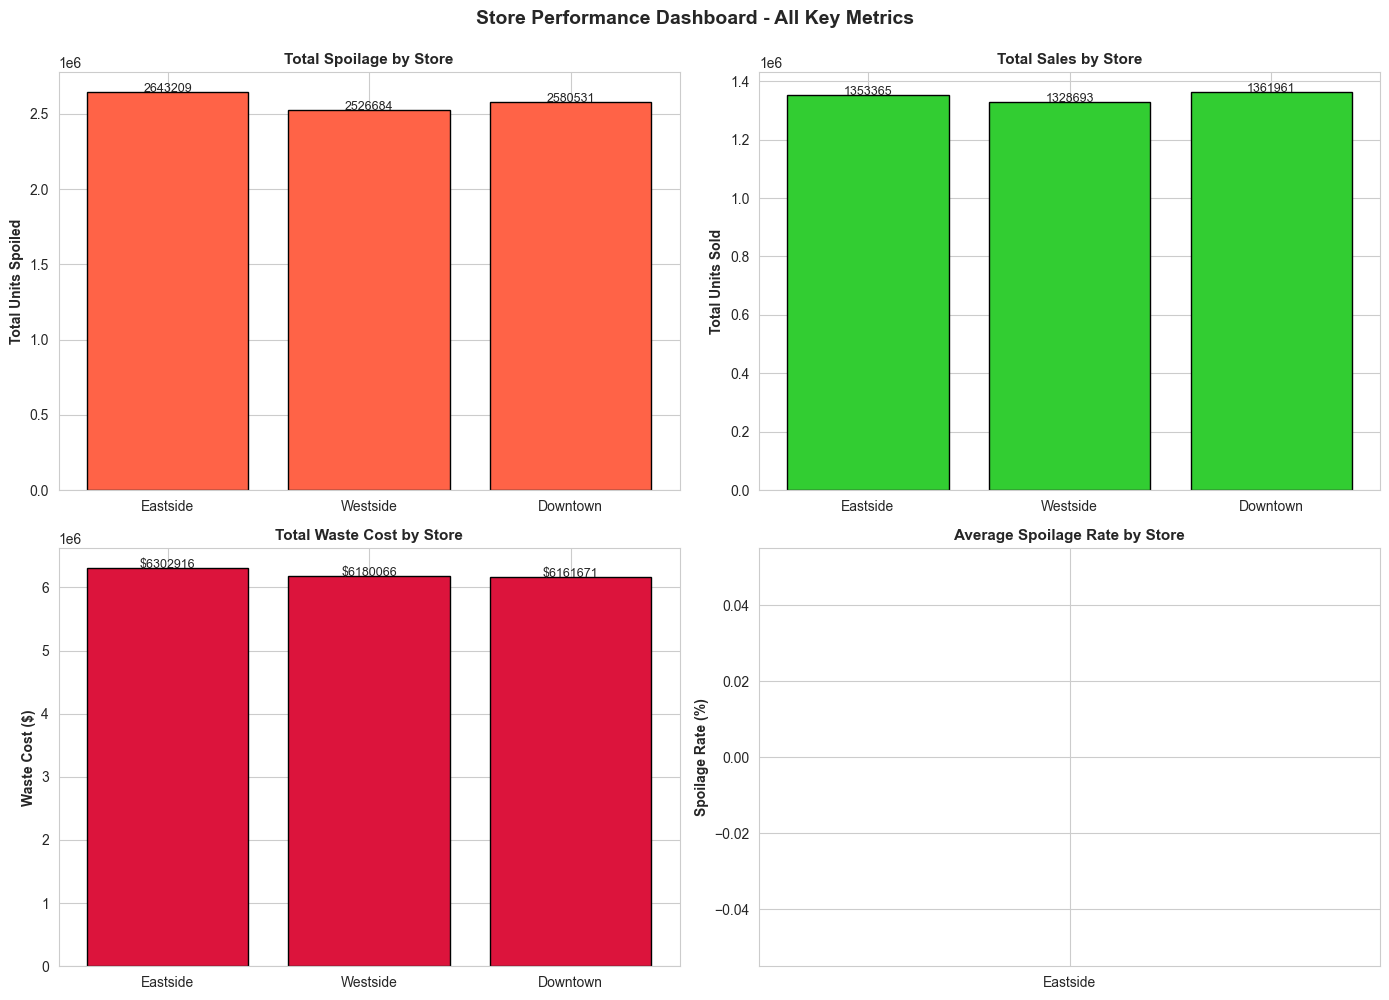

💡 INSIGHT: Complete store comparison shows operational differences
   ACTION: Share best practices from top-performing store


In [13]:
# VISUALIZATION 8: Store Performance Dashboard
# ============================================
print("\n" + "="*60)
print("[VIZ 8] Store Performance Comparison")
print("="*60)

fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(14, 10))

# Total spoilage
ax1.bar(q8['store_location'], q8['total_spoiled'], color='tomato', edgecolor='black')
ax1.set_ylabel('Total Units Spoiled', fontsize=10, fontweight='bold')
ax1.set_title('Total Spoilage by Store', fontsize=11, fontweight='bold')
for i, v in enumerate(q8['total_spoiled']):
    ax1.text(i, v + 50, str(int(v)), ha='center', fontsize=9)

# Total sales
ax2.bar(q8['store_location'], q8['total_sold'], color='limegreen', edgecolor='black')
ax2.set_ylabel('Total Units Sold', fontsize=10, fontweight='bold')
ax2.set_title('Total Sales by Store', fontsize=11, fontweight='bold')
for i, v in enumerate(q8['total_sold']):
    ax2.text(i, v + 500, str(int(v)), ha='center', fontsize=9)

# Waste cost
ax3.bar(q8['store_location'], q8['total_waste_cost'], color='crimson', edgecolor='black')
ax3.set_ylabel('Waste Cost ($)', fontsize=10, fontweight='bold')
ax3.set_title('Total Waste Cost by Store', fontsize=11, fontweight='bold')
for i, v in enumerate(q8['total_waste_cost']):
    ax3.text(i, v + 20, f'${v:.0f}', ha='center', fontsize=9)

# Spoilage rate
ax4.bar(q8['store_location'], q8['avg_spoilage_rate'], color='orange', edgecolor='black')
ax4.set_ylabel('Spoilage Rate (%)', fontsize=10, fontweight='bold')
ax4.set_title('Average Spoilage Rate by Store', fontsize=11, fontweight='bold')
for i, v in enumerate(q8['avg_spoilage_rate']):
    ax4.text(i, v + 0.05, f'{v:.2f}%', ha='center', fontsize=9)

plt.suptitle('Store Performance Dashboard - All Key Metrics', 
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig('viz8_store_dashboard.png', dpi=300, bbox_inches='tight')
plt.show()

print("💡 INSIGHT: Complete store comparison shows operational differences")
print("   ACTION: Share best practices from top-performing store")

In [14]:
# FINAL SUMMARY
# ============================================
print("\n" + "="*60)
print("DAY 5 COMPLETE - VISUALIZATION SUMMARY")
print("="*60)

print("\n📊 8 Visualizations Created:")
print("   ✓ viz1_top_spoilage_products.png")
print("   ✓ viz2_top_waste_cost.png")
print("   ✓ viz3_spoilage_by_store.png")
print("   ✓ viz4_spoilage_by_category.png")
print("   ✓ viz5_monthly_trend.png")
print("   ✓ viz6_weekend_weekday.png")
print("   ✓ viz7_high_waste_low_sales.png")
print("   ✓ viz8_store_dashboard.png")

print("\n💡 Key Business Insights:")
print("   1. Top 10 products drive majority of waste")
print("   2. Store performance varies significantly")
print("   3. Category-specific patterns identified")
print("   4. Seasonal trends discovered")
print("   5. Weekend vs weekday patterns clear")
print("   6. Low-performing products identified")
print("="*60)


DAY 5 COMPLETE - VISUALIZATION SUMMARY

📊 8 Visualizations Created:
   ✓ viz1_top_spoilage_products.png
   ✓ viz2_top_waste_cost.png
   ✓ viz3_spoilage_by_store.png
   ✓ viz4_spoilage_by_category.png
   ✓ viz5_monthly_trend.png
   ✓ viz6_weekend_weekday.png
   ✓ viz7_high_waste_low_sales.png
   ✓ viz8_store_dashboard.png

💡 Key Business Insights:
   1. Top 10 products drive majority of waste
   2. Store performance varies significantly
   3. Category-specific patterns identified
   4. Seasonal trends discovered
   5. Weekend vs weekday patterns clear
   6. Low-performing products identified
